In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df= pd.read_csv('data_science_job.csv')

In [6]:
df.head(2)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0


In [7]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [9]:
cols = [
    var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean()>0]
cols


['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [9]:
cols = [
    var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean()>0]
cols


['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [10]:
df[cols].sample(3)

,city_development_index,enrolled_university,education_level,experience,training_hours
4851,0.887,Full time course,High School,13.0,49.0
6827,0.556,no_enrollment,Graduate,6.0,46.0
6101,0.895,Full time course,Masters,1.0,13.0


In [13]:
#jab columns ko drop kar rahy ho to kitna nuqsan hua 

len(df[cols].dropna()) / len(df) #  = 89% data bachy ga sare nuqsan ke bad

0.8968577095730244

In [15]:
new_df = df[cols].dropna()
df.shape,new_df.shape #purana or naya df mil gya 

((19158, 13), (17182, 5))

In [1]:
#ab histogram bna le
sns.countplot(new_df)

NameError: name 'sns' is not defined

<Axes: >

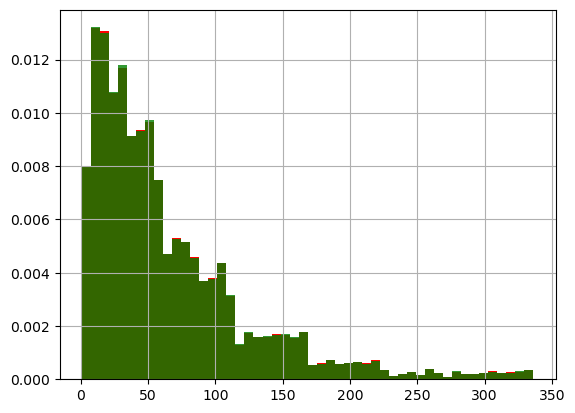

In [19]:
# ab after and before cca apply kr ke dekho 

fig= plt.figure()
ax= fig.add_subplot(111)
#original data
df['training_hours'].hist(bins=50,density=True,ax=ax, color='red')

#data after cca and see the overlap
new_df['training_hours'].hist(bins=50,density=True,ax=ax, color='green',alpha= 0.8)


In [20]:
#is se yeh pta chlta hai data completely missing hai randomly

In [22]:
temp = pd.concat([
    df['enrolled_university'].value_counts()/len(df),
    new_df['enrolled_university'].value_counts()/len(df),
],axis=1)
temp.columns=['original','cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


In [25]:
temp = pd.concat([
    df['education_level'].value_counts()/len(df),
    new_df['education_level'].value_counts()/len(df),
],axis=1)
temp.columns=['original','cca']
temp

,original,cca
education_level,,
Graduate,0.605387,0.555904
Masters,0.227633,0.209938
High School,0.105282,0.096304
Phd,0.021610,0.019835
Primary School,0.016077,0.014876


In [26]:
# part 2 ---- simple imputer 

In [29]:
#------- mean_median approach
import seaborn as sns 

In [32]:
df = sns.load_dataset('titanic')
df['family'] = df['sibsp'] + df['parch'] + 1


In [33]:
df = sns.load_dataset('titanic')
df = df[['age', 'fare', 'survived','family']]
df.head(3)

,age,fare,survived,family
0,22.0,7.2500,0,2
1,38.0,71.2833,1,2
2,26.0,7.9250,1,1


In [43]:
df.isnull().mean()

age         0.198653
fare        0.059484
survived    0.000000
family      0.000000
dtype: float64

In [42]:
import numpy as np

np.random.seed(42)

missing_idx = np.random.choice(
    df.index,
    size=int(0.05 * len(df)),
    replace=False
)

df.loc[missing_idx, 'fare'] = np.nan

In [48]:
from sklearn.model_selection import train_test_split
X= df.drop(columns=['survived'])
y=df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
X_train.isnull().mean()

age       0.196629
fare      0.000000
family    0.000000
dtype: float64

In [52]:
mean_age = X_train['age'].mean()
median_age = X_train['age'].median()

mean_age = X_train['fare'].mean()
mean_age = X_train['fare'].mean()

In [60]:
X_train['age_median']= X_train['age'].fillna(median_age)
X_train['age_mean']= X_train['age'].fillna(mean_age)

X_train['fare_median']= X_train['fare'].fillna(median_age)
X_train['fare_mean']= X_train['fare'].fillna(mean_age)

In [61]:
X_train.sample(5)

,age,fare,family,age_median,age_mean,fare_median,fare_mean
353,25.0,17.8000,2,25.0,25.0,17.8000,17.8000
634,9.0,27.9000,6,9.0,9.0,27.9000,27.9000
190,32.0,13.0000,1,32.0,32.0,13.0000,13.0000
332,38.0,153.4625,2,38.0,38.0,153.4625,153.4625
473,23.0,13.7917,1,23.0,23.0,13.7917,13.7917


<Axes: ylabel='Density'>

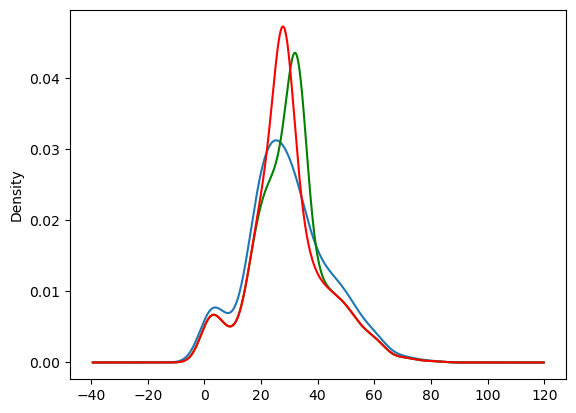

In [63]:
# ab after and before cca apply kr ke dekho 

fig= plt.figure()
ax= fig.add_subplot(111)
#original data
X_train['age'].plot(kind= 'kde', ax=ax)

#data after cca and see the overlap
X_train['age_mean'].plot(kind= 'kde',ax=ax, color='green')

X_train['age_median'].plot(kind= 'kde',ax=ax, color='red')


<Axes: ylabel='Density'>

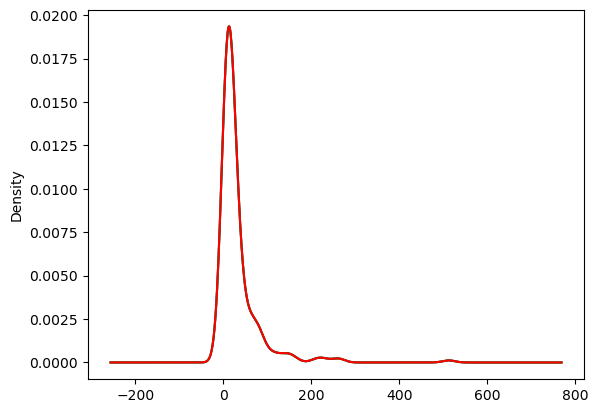

In [64]:
# ab after and before cca apply kr ke dekho 

fig= plt.figure()
ax= fig.add_subplot(111)
#original data
X_train['fare'].plot(kind= 'kde', ax=ax)

#data after cca and see the overlap
X_train['fare_mean'].plot(kind= 'kde',ax=ax, color='green')

X_train['fare_median'].plot(kind= 'kde',ax=ax, color='red')


In [65]:
X_train.cov()

,age,fare,family,age_median,age_mean,fare_median,fare_mean
age,210.251707,71.580633,-6.993325,210.251707,210.251707,71.580633,71.580633
fare,71.580633,2700.831981,18.495747,61.261919,49.708074,2700.831981,2700.831981
family,-6.993325,18.495747,2.830892,-5.587710,-5.675190,18.495747,18.495747
age_median,210.251707,61.261919,-5.587710,169.207310,168.119904,61.261919,61.261919
age_mean,210.251707,49.708074,-5.675190,168.119904,170.359820,49.708074,49.708074
fare_median,71.580633,2700.831981,18.495747,61.261919,49.708074,2700.831981,2700.831981
fare_mean,71.580633,2700.831981,18.495747,61.261919,49.708074,2700.831981,2700.831981


<Axes: >

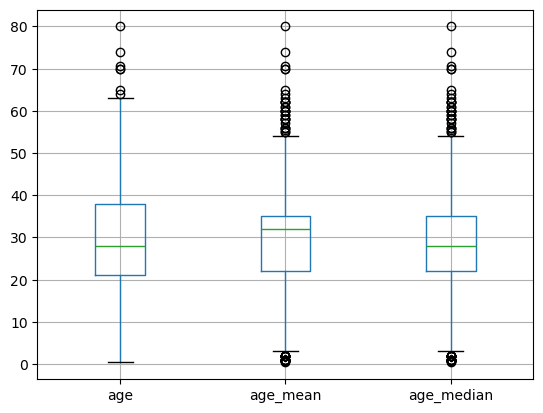

In [67]:
X_train[['age','age_mean','age_median']].boxplot()

<Axes: >

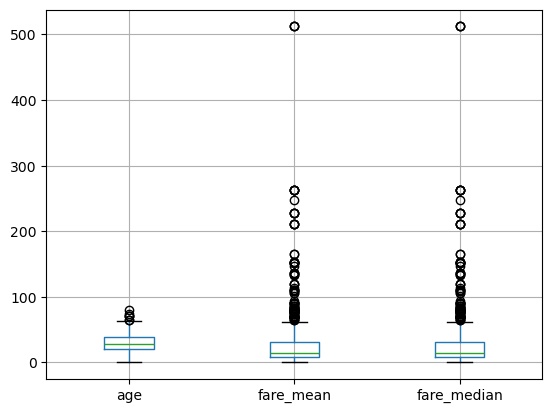

In [68]:
X_train[['age','fare_mean','fare_median']].boxplot()

In [69]:
#arbitary

In [70]:
X_train['age_99']= X_train['age'].fillna(99)
X_train['age_minus1']= X_train['age'].fillna(-1)

X_train['fare_999']= X_train['fare'].fillna(999)
X_train['fare_minus1']= X_train['fare'].fillna(-1)

<Axes: ylabel='Density'>

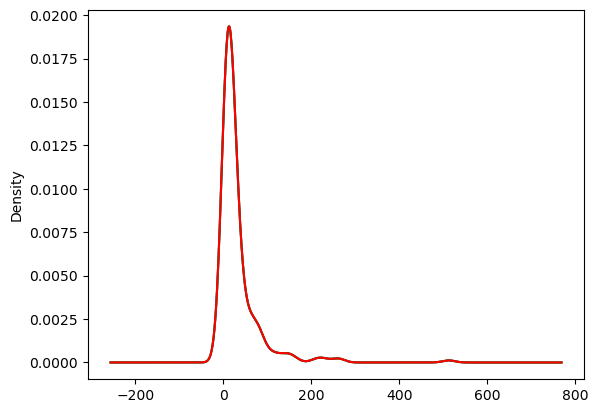

In [71]:
fig= plt.figure()
ax= fig.add_subplot(111)
#original data
X_train['fare'].plot(kind= 'kde', ax=ax)

#data after cca and see the overlap
X_train['fare_999'].plot(kind= 'kde',ax=ax, color='green')

X_train['fare_minus1'].plot(kind= 'kde',ax=ax, color='red')


<Axes: ylabel='Density'>

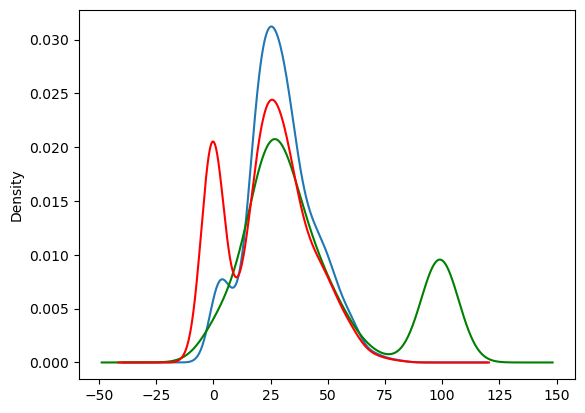

In [72]:
fig= plt.figure()
ax= fig.add_subplot(111)
#original data
X_train['age'].plot(kind= 'kde', ax=ax)

#data after cca and see the overlap
X_train['age_99'].plot(kind= 'kde',ax=ax, color='green')

X_train['age_minus1'].plot(kind= 'kde',ax=ax, color='red')

In [74]:
X_train.cov()

,age,fare,family,age_median,age_mean,fare_median,fare_mean,age_99,age_minus1,fare_999,fare_minus1
age,210.251707,71.580633,-6.993325,210.251707,210.251707,71.580633,71.580633,210.251707,210.251707,71.580633,71.580633
fare,71.580633,2700.831981,18.495747,61.261919,49.708074,2700.831981,2700.831981,-117.602795,134.319337,2700.831981,2700.831981
family,-6.993325,18.495747,2.830892,-5.587710,-5.675190,18.495747,18.495747,-6.941982,-5.034556,18.495747,18.495747
age_median,210.251707,61.261919,-5.587710,169.207310,168.119904,61.261919,61.261919,152.373211,176.083210,61.261919,61.261919
age_mean,210.251707,49.708074,-5.675190,168.119904,170.359820,49.708074,49.708074,202.795979,153.956437,49.708074,49.708074
fare_median,71.580633,2700.831981,18.495747,61.261919,49.708074,2700.831981,2700.831981,-117.602795,134.319337,2700.831981,2700.831981
fare_mean,71.580633,2700.831981,18.495747,61.261919,49.708074,2700.831981,2700.831981,-117.602795,134.319337,2700.831981,2700.831981
age_99,210.251707,-117.602795,-6.941982,152.373211,202.795979,-117.602795,-117.602795,932.966537,-166.460682,-117.602795,-117.602795
age_minus1,210.251707,134.319337,-5.034556,176.083210,153.956437,134.319337,134.319337,-166.460682,315.995504,134.319337,134.319337
fare_999,71.580633,2700.831981,18.495747,61.261919,49.708074,2700.831981,2700.831981,-117.602795,134.319337,2700.831981,2700.831981


In [150]:
t = pd.read_csv('train.csv')

In [151]:
t.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [152]:
t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [123]:
t = t[['GarageQual','FireplaceQu','SalePrice']]

In [124]:
t.head()

,GarageQual,FireplaceQu,SalePrice
0,TA,NaN,208500
1,TA,TA,181500
2,TA,TA,223500
3,TA,Gd,140000
4,TA,TA,250000


In [81]:
t.isnull().mean()*100

GarageQual      5.547945
FireplaceQu    47.260274
SalePrice       0.000000
dtype: float64

In [82]:
t['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

In [85]:
temp= t[t['GarageQual']=='TA']['SalePrice']

In [86]:
t['GarageQual'].fillna('TA',inplace=True)

C:\Users\me\AppData\Local\Temp\ipykernel_7608\3542387833.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  t['GarageQual'].fillna('TA',inplace=True)


<Axes: xlabel='GarageQual'>

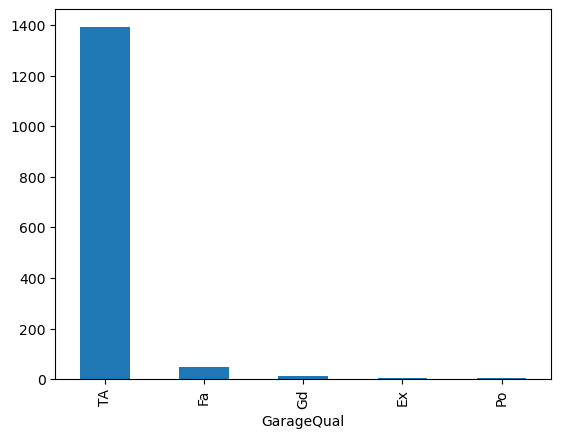

In [89]:
t['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

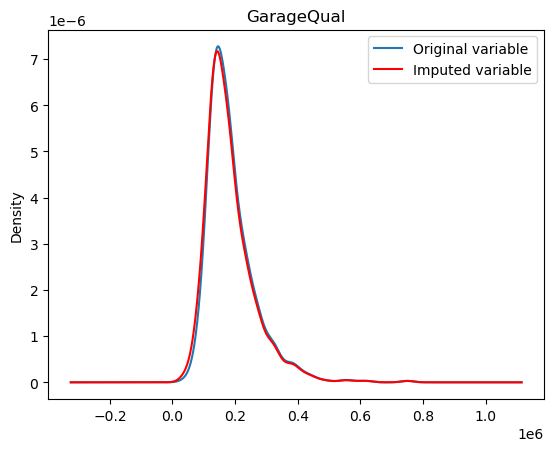

In [90]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
t[t['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

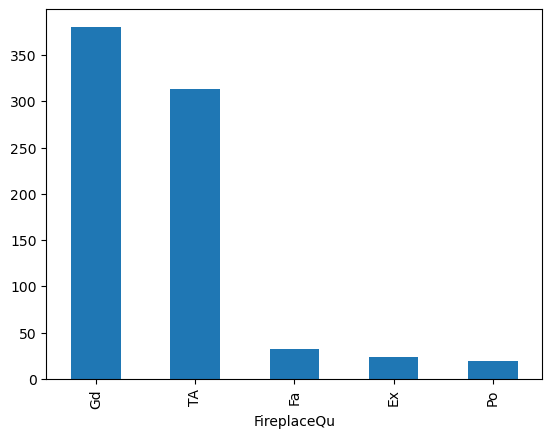

In [97]:
t['FireplaceQu'].value_counts().plot(kind='bar')

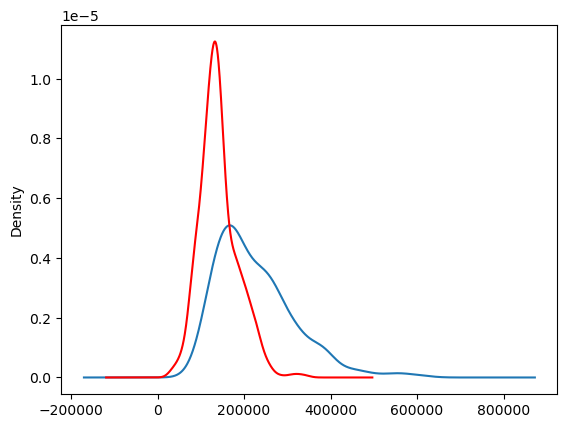

In [99]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)

t[t['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

t[t['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']


In [153]:
df = sns.load_dataset('titanic')
df = df[['age', 'fare', 'survived']]
df.head(3)

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1


In [154]:
X= df.drop(columns=['survived'])
y=df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [102]:
X_train['age_imputer']=X_train['age']
X_test['age_imputer']=X_test['age']

In [109]:
X_train.loc[X_train['age_imputer'].isnull(), 'age_imputer'] = (
    X_train['age'].dropna()
    .sample(X_train['age_imputer'].isnull().sum(), random_state=42)
    .values
)

In [110]:
X_test.loc[X_test['age_imputer'].isnull(), 'age_imputer'] = (
    X_test['age'].dropna()
    .sample(X_test['age_imputer'].isnull().sum(), random_state=42)
    .values
)

In [113]:
X_test

,age,fare,age_imputer
709,NaN,15.2458,23.0
439,31.0,10.5000,31.0
840,20.0,7.9250,20.0
720,6.0,33.0000,6.0
39,14.0,11.2417,14.0
...,...,...,...
433,17.0,7.1250,17.0
773,NaN,7.2250,49.0
25,38.0,31.3875,38.0
84,17.0,10.5000,17.0


C:\Users\me\AppData\Local\Temp\ipykernel_7608\381127407.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['age'],label='Original',hist=False)
C:\Users\me\AppData\Local\Temp\ipykernel_7608\381127407.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['age_imput

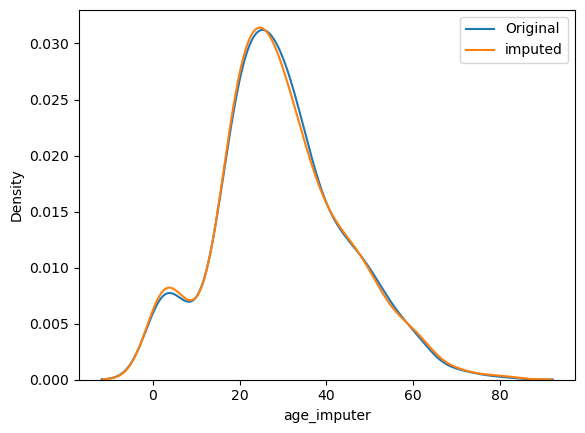

In [116]:
sns.distplot(X_train['age'],label='Original',hist=False)
sns.distplot(X_train['age_imputer'],label='imputed',hist=False)
plt.legend()
plt.show()

In [118]:
X_train[['age', 'fare', 'age_imputer']].cov()


,age,fare,age_imputer
age,210.251707,71.580633,210.251707
fare,71.580633,2700.831981,51.715036
age_imputer,210.251707,51.715036,217.511700


<Axes: >

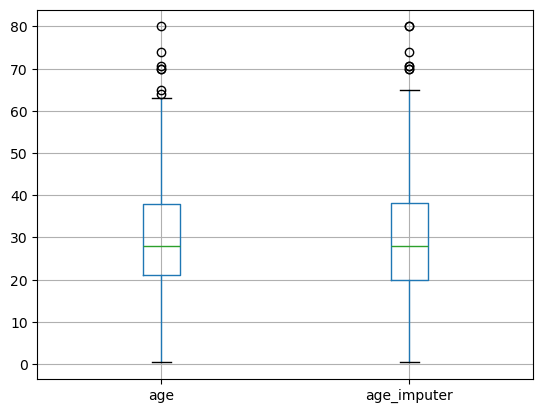

In [119]:
X_train[['age','age_imputer']].boxplot()

In [125]:
t.isnull().mean()*100

GarageQual      5.547945
FireplaceQu    47.260274
SalePrice       0.000000
dtype: float64

In [126]:
X= t
y=t['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [127]:
X_train['GarageQual_imputed']=X_train['GarageQual']
X_test['GarageQual_imputed']=X_test['GarageQual']

X_train['FireplaceQu_imputed']=X_train['FireplaceQu']
X_test['FireplaceQu_imputed']=X_test['FireplaceQu']

In [128]:
X_train.head(3)

,GarageQual,FireplaceQu,SalePrice,GarageQual_imputed,FireplaceQu_imputed
254,TA,NaN,145000,TA,NaN
1066,TA,TA,178000,TA,TA
638,NaN,NaN,85000,NaN,NaN


In [129]:
#missing indicators

In [130]:
df.head()

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [156]:
from sklearn.impute import MissingIndicator,SimpleImputer

In [157]:
mi = MissingIndicator()
mi.fit(X_train)

MissingIndicator()

In [158]:
mi.features_

array([0])

In [159]:
X_train_missing = mi.transform(X_train)

In [160]:
X_train_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [161]:
X_test_missing = mi.transform(X_test)

In [146]:
X_test_missing

array([[False,  True, False,  True],
       [False, False, False, False],
       [False, False, False, False],
       ...,
       [False, False, False, False],
       [False, False, False, False],
       [False,  True, False,  True]])

In [162]:
X_train['age_na'] = X_train['age'].isnull().astype(int)

In [164]:
X_test['age_na'] = X_test_missing.astype(int)

In [167]:
si = SimpleImputer(add_indicator=True)

In [168]:
X_train = si.fit_transform(X_train)

In [169]:
X_test = si.transform(X_test)

In [171]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train_trf2,y_train)
y_pred = clf.predict(X_test_trf2)

NameError: name 'X_train_trf2' is not defined